In [1]:
from coffea.nanoevents import NanoAODSchema
from coffea.dataset_tools import apply_to_fileset, max_chunks, max_files, preprocess

import dask

from analysis_tools.iso_signal_processor_old import SignalProcessor


/cvmfs/sft-nightlies.cern.ch/lcg/views/devswan/Mon/x86_64-el9-gcc13-opt/lib/python3.11/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [2]:
import gzip
import json
import os

# Define the base directory where the preprocessed files are stored
base_dir = "/eos/user/d/dgrove/Ph2_analysis/tools/preprocessing/preprocessed"
signal_sample = "2023_SlepSnu_MN1_270_100000_preprocessed_available.json.gz"
background_sample = "2023_ttbar_100000_preprocessed_available.json.gz"
signal_file_path = os.path.join(base_dir, signal_sample)
background_file_path = os.path.join(base_dir, background_sample)
#print(preprocessed)

with gzip.open(signal_file_path, "rt") as file:
    signal_preprocessed_available = json.load(file)
with gzip.open(background_file_path, "rt") as file:
    background_preprocessed_available = json.load(file)

In [3]:
signal_test_preprocessed_files = max_files(signal_preprocessed_available, 3)
signal_test_preprocessed = max_chunks(signal_test_preprocessed_files, 3)

### SWITCH HERE ###

signal_reduced_computation = True

###################

# signal

if signal_reduced_computation:
    small_tg, small_rep = apply_to_fileset(
        data_manipulation=SignalProcessor(),
        fileset=signal_test_preprocessed,
        schemaclass=NanoAODSchema,
        uproot_options={"allow_read_errors_with_report": (OSError, KeyError)},
    )
    signal_computed, rep = dask.compute(small_tg, small_rep)
    
else:
    full_tg, full_rep = apply_to_fileset(
        data_manipulation=SignalProcessor(),
        fileset=signal_preprocessed_available,
        schemaclass=NanoAODSchema,
        uproot_options={"allow_read_errors_with_report": (OSError, KeyError)},
    )
    signal_computed, rep = dask.compute(full_tg, full_rep)


In [4]:

sig_results = signal_computed['/SlepSnuCascade_MN1-270_MN2-280_MC1-275_TuneCP5_13p6TeV_madgraphMLM-pythia8/Run3Summer23BPixNanoAODv12-130X_mcRun3_2023_realistic_postBPix_v6-v3/NANOAODSIM']



In [5]:
sig_results

{'counts': {'total_entries': 303452,
  'count_ele': 228295,
  'count_filtered_ele': 48104,
  'events_filtered_ele': 46219,
  'count_disambig_ele': 37334,
  'events_disambig_ele': 36093,
  'count_cust_ele': 32670,
  'events_cust_ele': 31810,
  'count_bronze_ele': 29237,
  'events_bronze_ele': 28460,
  'count_silver_ele': 3011,
  'events_silver_ele': 3006,
  'count_gold_ele': 19454,
  'events_gold_ele': 19170,
  'count_true_bronze_ele': 6772,
  'events_true_bronze_ele': 6617,
  'test_0': 19768,
  'test_1': <Array [[], [], [], [], ..., [], [], [], []] type='303452 * var * float32[p...'>,
  'test_2': <Array [[], [], [], [], ..., [], [], [], []] type='303452 * var * float32[p...'>},
 'calculations': {'ele_num': {'pfRelIso03_all': {(5, 6): 1353,
    (6, 7): 1212,
    (7, 8): 1078,
    (8, 9): 861,
    (9, 10): 695,
    (10, 11): 614,
    (11, 12): 501,
    (12, 13): 516,
    (13, 14): 486,
    (14, 15): 448,
    (15, 20): 2279,
    (20, 25): 2101,
    (25, 30): 2264,
    (30, 100): 14047},
 

In [6]:
sig_results["tests"]["vid_map"]

<Array [[613566756], [], ..., [609372452], []] type='303452 * var * int32[p...'>

In [7]:
sig_counts = sig_results["counts"]
sig_counts

{'total_entries': 303452,
 'count_ele': 228295,
 'count_filtered_ele': 48104,
 'events_filtered_ele': 46219,
 'count_disambig_ele': 37334,
 'events_disambig_ele': 36093,
 'count_cust_ele': 32670,
 'events_cust_ele': 31810,
 'count_bronze_ele': 29237,
 'events_bronze_ele': 28460,
 'count_silver_ele': 3011,
 'events_silver_ele': 3006,
 'count_gold_ele': 19454,
 'events_gold_ele': 19170,
 'count_true_bronze_ele': 6772,
 'events_true_bronze_ele': 6617,
 'test_0': 19768,
 'test_1': <Array [[], [], [], [], ..., [], [], [], []] type='303452 * var * float32[p...'>,
 'test_2': <Array [[], [], [], [], ..., [], [], [], []] type='303452 * var * float32[p...'>}

In [8]:
count_ele = sig_counts["count_ele"]
count_bronze_ele = sig_counts["count_bronze_ele"]

In [9]:
sig_plots = sig_results["plots"]
sig_plots
sig_plots_2d = sig_results["plots_2d"]
sig_plots_2d

{'gold_pt_mini_iso_dist': Hist(
   Regular(100, 0, 0.3, name='mini_iso'),
   Regular(100, 5, 30, name='pT'),
   storage=Double()) # Sum: 8966.0 (19768.0 with flow),
 'gold_pt_pfrel_iso_dist': Hist(
   Regular(100, 0, 0.3, name='pfrel_iso'),
   Regular(100, 5, 30, name='pT'),
   storage=Double()) # Sum: 9020.0 (19768.0 with flow),
 'gold_eta_mini_iso_dist': Hist(
   Regular(100, 0, 0.3, name='mini_iso'),
   Regular(100, -2.5, 2.5, name='eta'),
   storage=Double()) # Sum: 19710.0 (19768.0 with flow),
 'gold_eta_pfrel_iso_dist': Hist(
   Regular(100, 0, 0.3, name='pfrel_iso'),
   Regular(100, -2.5, 2.5, name='eta'),
   storage=Double()) # Sum: 19768.0}

In [10]:
import matplotlib.pyplot as plt
import mplhep

In [11]:
#have to call this a second time to get proper scaling, a known bug
#mplhep.style.use(mplhep.style.CMS)
#plt.figure()
#mplhep.style.use(mplhep.style.CMS)

<Figure size 432x288 with 0 Axes>

In [12]:
"""
plt.figure()
fig, ax = plt.subplots(figsize=(10, 6))

ele_mini_iso = sig_plots["ele_mini_iso"]
#ele_count = sig_plots["count_ele"]

ele_mini_iso.plot1d(ax=ax, label="SlepSnu 270")
entries = ele_mini_iso.sum()

plt.xlabel("miniPFRelIso")
plt.ylabel("Counts")
plt.yscale("log")

ax.text(
    0.95, 0.8,  # Position in axis coordinates (1=top right, 0=bottom left)
    f"Entries: {int(entries)}", 
    transform=ax.transAxes,  # Ensures coordinates are relative to the axis
    fontsize=15,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(facecolor='white', alpha=0.5, edgecolor='black')  # Add a background box
)

#ax.axvline(x=5, color='black', linestyle=':', linewidth=2)
plt.title("electrons: miniPFRelIso_all (no cuts)", pad=25)  # Adjust title position
mplhep.cms.label(loc=0, fontsize=15)  # Move CMS label to a different position
plt.legend()

print(f"Total histogram entries: {entries}")
"""

'\nplt.figure()\nfig, ax = plt.subplots(figsize=(10, 6))\n\nele_mini_iso = sig_plots["ele_mini_iso"]\n#ele_count = sig_plots["count_ele"]\n\nele_mini_iso.plot1d(ax=ax, label="SlepSnu 270")\nentries = ele_mini_iso.sum()\n\nplt.xlabel("miniPFRelIso")\nplt.ylabel("Counts")\nplt.yscale("log")\n\nax.text(\n    0.95, 0.8,  # Position in axis coordinates (1=top right, 0=bottom left)\n    f"Entries: {int(entries)}", \n    transform=ax.transAxes,  # Ensures coordinates are relative to the axis\n    fontsize=15,\n    verticalalignment="top",\n    horizontalalignment="right",\n    bbox=dict(facecolor=\'white\', alpha=0.5, edgecolor=\'black\')  # Add a background box\n)\n\n#ax.axvline(x=5, color=\'black\', linestyle=\':\', linewidth=2)\nplt.title("electrons: miniPFRelIso_all (no cuts)", pad=25)  # Adjust title position\nmplhep.cms.label(loc=0, fontsize=15)  # Move CMS label to a different position\nplt.legend()\n\nprint(f"Total histogram entries: {entries}")\n'

In [13]:
"""
def plot_all_histograms(hist_dict, dataset_label="SlepSnu 270"):
    
    for hist_name, hist_obj in hist_dict.items():
        plt.figure()
        fig, ax = plt.subplots(figsize=(10, 6))

        # Plot histogram
        hist_obj.plot1d(ax=ax, label=dataset_label)

        # Compute total entries
        total_entries = hist_obj.sum()

        # Add text annotation for total count inside the plot
        ax.text(
            0.95, 0.8,  # Position in axis coordinates (1=top right, 0=bottom left)
            f"Entries: {int(total_entries)}", 
            transform=ax.transAxes,  
            fontsize=15,
            verticalalignment="top",
            horizontalalignment="right",
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='black')  
        )

        # Labels and formatting
        plt.xlabel(hist_name.replace("_", " "))  # Format variable name as label
        plt.ylabel("Counts")
        plt.yscale("log")
        plt.title(f"{hist_name} Distribution", pad=25)
        
        # CMS label
        mplhep.cms.label(loc=0, fontsize=15)

        plt.legend()
        plt.show()

        # Print total entries for debugging
        print(f"Total histogram entries for {hist_name}: {int(total_entries)}")
"""


'\ndef plot_all_histograms(hist_dict, dataset_label="SlepSnu 270"):\n    \n    for hist_name, hist_obj in hist_dict.items():\n        plt.figure()\n        fig, ax = plt.subplots(figsize=(10, 6))\n\n        # Plot histogram\n        hist_obj.plot1d(ax=ax, label=dataset_label)\n\n        # Compute total entries\n        total_entries = hist_obj.sum()\n\n        # Add text annotation for total count inside the plot\n        ax.text(\n            0.95, 0.8,  # Position in axis coordinates (1=top right, 0=bottom left)\n            f"Entries: {int(total_entries)}", \n            transform=ax.transAxes,  \n            fontsize=15,\n            verticalalignment="top",\n            horizontalalignment="right",\n            bbox=dict(facecolor=\'white\', alpha=0.5, edgecolor=\'black\')  \n        )\n\n        # Labels and formatting\n        plt.xlabel(hist_name.replace("_", " "))  # Format variable name as label\n        plt.ylabel("Counts")\n        plt.yscale("log")\n        plt.title(f"{hi

In [14]:
#plot_all_histograms(sig_plots)

In [15]:

def plot_all_histograms(hist_dict, dataset_label="SlepSnu 270", save_dir="hist_plots", save_format="png"):
    """
    Loops through a dictionary of histograms, generates plots, and saves them.

    Parameters:
    - hist_dict: dict -> Dictionary containing histograms.
    - dataset_label: str -> Label for legend (default: "SlepSnu 270").
    - save_dir: str -> Directory where plots will be saved (default: "hist_plots").
    - save_format: str -> Image format (default: "png"). Can be "png", "pdf", etc.
    """

    # Ensure the directory exists
    os.makedirs(save_dir, exist_ok=True)

    for hist_name, hist_obj in hist_dict.items():
        plt.figure()
        fig, ax = plt.subplots(figsize=(10, 6))

        # Plot histogram
        hist_obj.plot1d(ax=ax, label=dataset_label)

        # Compute total entries
        total_entries = hist_obj.sum()

        # Add text annotation for total count inside the plot
        ax.text(
            0.95, 0.8,  
            f"Entries: {int(total_entries)}", 
            transform=ax.transAxes,  
            fontsize=15,
            verticalalignment="top",
            horizontalalignment="right",
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='black')  
        )

        # Labels and formatting
        plt.xlabel(hist_name.replace("_", " "))  
        plt.ylabel("Counts")
        plt.yscale("log")
        plt.title(f"{hist_name} Distribution", pad=25)
        
        # CMS label
        mplhep.cms.label(loc=0, fontsize=15)

        plt.legend()

        # Save plot to file
        save_path = os.path.join(save_dir, f"{hist_name}.{save_format}")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")  # High-quality save

        # Show plot
        plt.show()

        # Print total entries for debugging
        print(f"Total histogram entries for {hist_name}: {int(total_entries)}")



In [16]:
#plot_all_histograms(sig_plots)

In [17]:
import matplotlib.colors as colors

def plot_all_2d_histograms(hist_dict, dataset_label="SlepSnu 270", save_dir="2d_hist_plots", save_format="png"):
    """
    Loops through a dictionary of 2D histograms, generates plots, and saves them.

    Parameters:
    - hist_dict: dict -> Dictionary containing 2D histograms.
    - dataset_label: str -> Label for legend (default: "SlepSnu 270").
    - save_dir: str -> Directory where plots will be saved (default: "hist_plots_2d").
    - save_format: str -> Image format (default: "png"). Can be "png", "pdf", etc.
    """

    # Ensure the directory exists
    os.makedirs(save_dir, exist_ok=True)

    for hist_name, hist_obj in hist_dict.items():
        plt.figure()
        fig, ax = plt.subplots(figsize=(10, 6))

        # Extract axis names
        x_axis_name = hist_obj.axes[0].name.replace("_", " ")
        y_axis_name = hist_obj.axes[1].name.replace("_", " ")

        # Plot 2D histogram using plot2d with logarithmic normalization
        hist_obj.plot2d(ax=ax, norm=colors.LogNorm(), label=f"{hist_name} vs {y_axis_name}")

        # Compute total entries
        total_entries = hist_obj.sum()

        # Add text annotation for total count inside the plot
        props = dict(boxstyle='round', facecolor='white', alpha=0.1)
        ax.text(0.65, 0.95, f"Entries: {int(total_entries)}", transform=ax.transAxes, 
                bbox=props, verticalalignment='top')

        # Labels and formatting
        plt.xlabel(x_axis_name)
        plt.ylabel(y_axis_name)
        plt.title(f"{hist_name} {y_axis_name} vs {x_axis_name}", pad=20)  # Adjust title position
        
        # CMS label
        mplhep.cms.label(loc=1)  # Move CMS label to a different position

        # Save plot to file
        save_path = os.path.join(save_dir, f"{hist_name}.{save_format}")
        plt.savefig(save_path, dpi=120, bbox_inches="tight")  # High-quality save

        # Show plot
        plt.show()

        # Print total entries for debugging
        print(f"Total histogram entries for {hist_name}: {int(total_entries)}")


<Figure size 720x720 with 0 Axes>

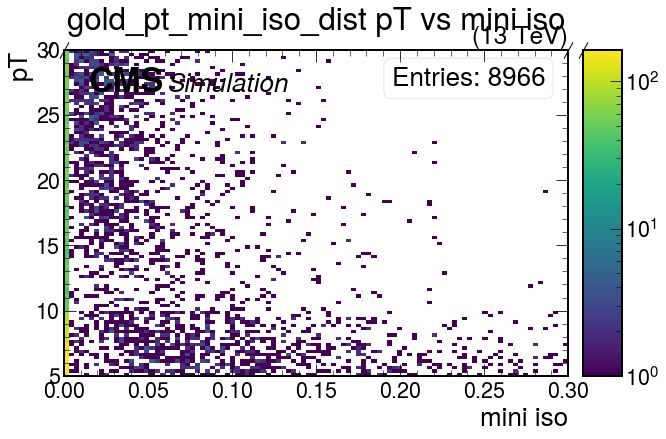

Total histogram entries for gold_pt_mini_iso_dist: 8966


<Figure size 720x720 with 0 Axes>

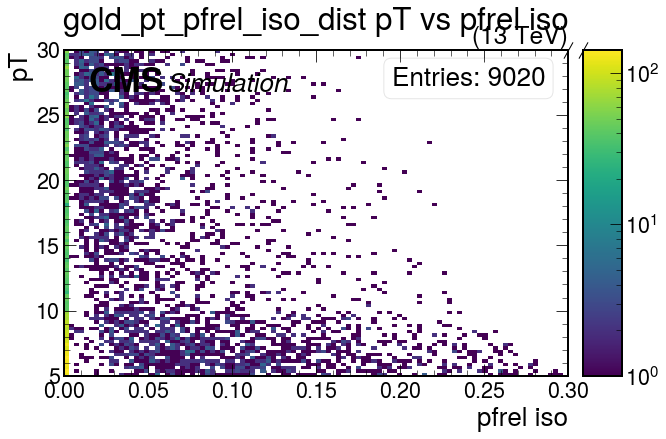

Total histogram entries for gold_pt_pfrel_iso_dist: 9020


<Figure size 720x720 with 0 Axes>

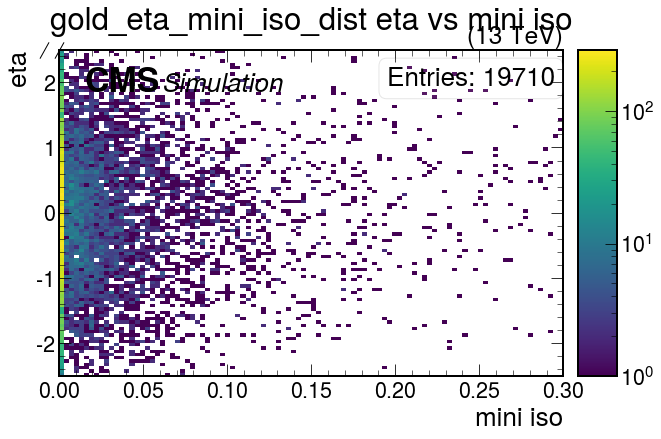

Total histogram entries for gold_eta_mini_iso_dist: 19710


<Figure size 720x720 with 0 Axes>

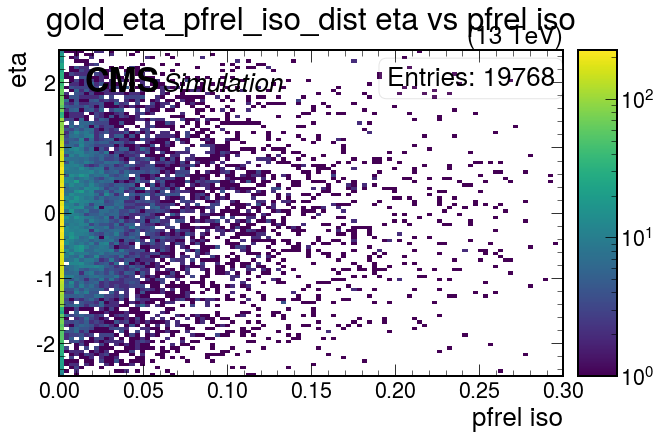

Total histogram entries for gold_eta_pfrel_iso_dist: 19768


In [18]:
plot_all_2d_histograms(sig_plots_2d)